# Freddie Mac — 06E controlled experiment: 10F minus macroeconomic variables



It reproduces the same internal Train split and VIF-reduction path used by the supplied controlled template, then starts from the specified **10F feature set** and removes the three macroeconomic predictors: `Housing_HPI_Growth_12M`, `BLS_Unemployment_Rate_Change_12M_Final`, and `Regular_MSA_Macro_Cluster_A`. The final modeling matrix therefore contains exactly **7 features**.



Logistic Regression, CatBoost and LightGBM use the fixed parameters selected in the 12F experiment. **No new hyperparameter search is performed.** The internal stratified 80/20 split (`random_state=3217`), five-fold overfit diagnosis, decision threshold 0.015, original `my_ml.fit_pipeline()` preprocessing and CatBoost fit-time categorical declaration are retained from the supplied controlled template.



The `Original_DTI` values originally missing were imputed upstream to 35. `DTI_Missing` preserves their original missing status. This notebook does not re-impute DTI or change the upstream parquet. Use Restart & Run All, with the project `helpers` module and ML-ready parquet available.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from helpers import *
PROJECT_NAME = "SFLLD_06E_7F_NoMacro_DTI_Missing_3models_controlled_fixed12Fparams"
RANDOM_STATE = 3217
TEST_SIZE = 0.20
THRESHOLD = 0.015
VIF_THRESHOLD = 10.0
TARGET = "Target_24M"
GAP_THRESHOLD = 0.20
print("PROJECT_NAME =", PROJECT_NAME)
print("RANDOM_STATE =", RANDOM_STATE)
print("THRESHOLD    =", THRESHOLD)

PROJECT_NAME = SFLLD_06E_7F_NoMacro_DTI_Missing_3models_controlled_fixed12Fparams
RANDOM_STATE = 3217
THRESHOLD    = 0.015


In [2]:
DATA_CANDIDATES = [
    Path(r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("../data/output/model_ready/SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("data/output/model_ready/SFLLD_regular_PIT_train_ML_ready.parquet"),
    Path("SFLLD_regular_PIT_train_ML_ready.parquet"),
]
DATA_PATH = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find SFLLD_regular_PIT_train_ML_ready.parquet. Searched:\n"
        + "\n".join(str(p.resolve()) for p in DATA_CANDIDATES)
    )
df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet
Shape : 160,003 rows x 56 columns


,Loan_ID,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,...,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Final,BLS_Employment_Growth_12M_Final,BLS_Unemployment_Rate_Change_12M_Final,Regular_State_Macro_Cluster_A,Regular_State_Macro_Cluster_B,Regular_MSA_Macro_Cluster_A,Regular_MSA_Macro_Cluster_A_Fallback,Regular_MSA_Macro_Cluster_B,Regular_MSA_Macro_Cluster_B_Fallback
0,F10Q20367887,752.0,2017-02-01,1,2040-06-01,235,0.0,0,1,65.0,...,0.041253,1.360977,0.031252,-0.1,1,2,0,0,0,0
1,F12Q40587216,791.0,2014-02-01,1,2044-01-01,452,0.0,0,1,38.0,...,0.122742,2.091864,0.018115,-0.9,1,1,0,1,1,1
2,F12Q40587224,708.0,2014-01-01,1,2043-12-01,435,0.0,0,1,64.0,...,0.031745,1.902108,0.002431,-1.1,2,1,0,0,0,0
3,F12Q40590818,682.0,2014-02-01,1,2042-12-01,99,0.0,0,1,62.0,...,0.066397,1.722767,0.032153,-0.8,1,1,1,0,1,0
4,F12Q40593033,787.0,2015-03-01,1,2028-01-01,282,0.0,0,1,55.0,...,0.038772,1.547563,0.013646,-0.7,2,2,1,0,0,0


In [3]:
# Same categorical definition and set_type() behavior as the two original notebooks.
CATEGORICAL_COLS = [
    "First_Time_Homebuyer","MSA","Number_of_Units","Occupancy_Status","Channel",
    "Property_State","Property_Type","Postal_Code","Loan_Purpose","Seller_Name",
    "Super_Conforming_Flag","HARP_Indicator","DTI_Missing","FICO_Risk_Band",
    "DTI_Risk_Band","LTV_Risk_Component","CLTV_Risk_Component","High_Leverage",
    "HARP_High_Leverage","Spatial_Cluster","Spatial_Cluster_Region",
    "Regular_State_Macro_Cluster_A","Regular_State_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A","Regular_MSA_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A_Fallback","Regular_MSA_Macro_Cluster_B_Fallback",
]
available_categorical = [c for c in CATEGORICAL_COLS if c in df.columns]
df = my_qtcheck.set_type(df, as_category=available_categorical)
failed = [
    c for c in available_categorical
    if not (
        isinstance(df[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(df[c].dtype)
    )
]
if failed:
    raise TypeError("Categorical conversion FAILED: " + str(failed))
print(f"✓ TYPE CONVERSION VERIFIED: {len(available_categorical)} categorical variables")

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  category      
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  category      
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  category      
 8   Occupancy_Status                        160003 non-null  category      
 9   Original_CLTV                           160003 n

In [4]:
# Same original 14-variable M8 candidate pool.
M8 = [
    "FICO_Score", "Original_DTI", "Original_CLTV",
    "Original_Interest_Rate", "Number_of_Borrowers", "Original_UPB",
    "DTI_LTV_Interaction", "DTI_Rate_Interaction",
    "DTI_Missing", "HARP_High_Leverage", "Spatial_Cluster_Region",
    "Housing_HPI_Growth_12M", "BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]
missing = [c for c in M8 + [TARGET] if c not in df.columns]
if missing:
    raise KeyError(f"Required columns missing: {missing}")
M8_CATEGORICAL = [c for c in M8 if c in CATEGORICAL_COLS]
M8_CONTINUOUS = [c for c in M8 if c not in CATEGORICAL_COLS]
rows = []
for c in M8:
    is_cat = (
        isinstance(df[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(df[c].dtype)
    )
    expected = "Categorical" if c in M8_CATEGORICAL else "Continuous"
    passed = is_cat if expected == "Categorical" else pd.api.types.is_numeric_dtype(df[c])
    rows.append([c, expected, str(df[c].dtype), df[c].nunique(dropna=True), is_cat, passed])
type_audit = pd.DataFrame(
    rows,
    columns=["Feature","Expected_Type","Actual_dtype","N_Unique","Detected_As_Categorical","PASS"]
)
display(type_audit)
bad = type_audit.loc[~type_audit.PASS, "Feature"].tolist()
if bad:
    raise TypeError(f"TYPE AUDIT FAILED — ML blocked: {bad}")
print("✓ TYPE AUDIT PASSED")

,Feature,Expected_Type,Actual_dtype,N_Unique,Detected_As_Categorical,PASS
0,FICO_Score,Continuous,float64,355,False,True
1,Original_DTI,Continuous,float64,50,False,True
2,Original_CLTV,Continuous,float64,226,False,True
3,Original_Interest_Rate,Continuous,float64,696,False,True
4,Number_of_Borrowers,Continuous,int64,2,False,True
5,Original_UPB,Continuous,int64,709,False,True
6,DTI_LTV_Interaction,Continuous,float64,1768,False,True
7,DTI_Rate_Interaction,Continuous,float64,2762,False,True
8,DTI_Missing,Categorical,category,2,True,True
9,HARP_High_Leverage,Categorical,category,2,True,True


✓ TYPE AUDIT PASSED


In [5]:
# Rebuild the SAME split from the SAME 14-variable M8 pool.
X_all = df[M8].copy()
y_all = df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)
print(f"Full dataset   : {len(df):,}")
print(f"Internal train : {len(X_train):,}")
print(f"Internal test  : {len(X_test):,}")
print("Train/Test index overlap:", len(set(X_train.index) & set(X_test.index)))
print("\nTrain target rate:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest target rate:")
print(y_test.value_counts(normalize=True).sort_index())

Full dataset   : 160,003
Internal train : 128,002
Internal test  : 32,001
Train/Test index overlap: 0

Train target rate:
Target_24M
0    0.994258
1    0.005742
Name: proportion, dtype: float64

Test target rate:
Target_24M
0    0.99425
1    0.00575
Name: proportion, dtype: float64


In [6]:
# Same hierarchy-preserving VIF reduction as the original corrected-M8 notebooks.
def vif_table(data, columns):
    x = data[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.isna().any().any():
        raise ValueError(
            f"VIF input has missing/non-finite values: {x.columns[x.isna().any()].tolist()}"
        )
    xc = add_constant(x, has_constant="add")
    return (
        pd.DataFrame([
            {"Feature": col, "VIF": variance_inflation_factor(xc.values, i)}
            for i, col in enumerate(x.columns, start=1)
        ])
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )
INTERACTION_PRIORITY = ["DTI_Rate_Interaction", "DTI_LTV_Interaction"]
continuous_final = M8_CONTINUOUS.copy()
removed_for_vif = []
while True:
    vt = vif_table(X_train, continuous_final)
    if vt.VIF.max() <= VIF_THRESHOLD:
        break
    offenders = vt.loc[vt.VIF > VIF_THRESHOLD, "Feature"].tolist()
    drop_col = next(
        (c for c in INTERACTION_PRIORITY if c in offenders and c in continuous_final),
        None,
    )
    if drop_col is None:
        drop_col = vt.iloc[0].Feature
    continuous_final.remove(drop_col)
    removed_for_vif.append(drop_col)
    print("Removed for VIF:", drop_col)
    if len(continuous_final) < 2:
        raise RuntimeError("Too few continuous predictors remain.")
vif_final = vif_table(X_train, continuous_final)
display(vif_final)
print("Removed for VIF:", removed_for_vif)
assert (vif_final.VIF <= VIF_THRESHOLD).all()
print("✓ FINAL VIF CHECK PASSED")

Removed for VIF: DTI_Rate_Interaction
Removed for VIF: DTI_LTV_Interaction


,Feature,VIF
0,Original_Interest_Rate,1.226023
1,Original_CLTV,1.107899
2,Original_UPB,1.100411
3,FICO_Score,1.088102
4,BLS_Unemployment_Rate_Change_12M_Final,1.085848
5,Housing_HPI_Growth_12M,1.083098
6,Original_DTI,1.062070
7,Number_of_Borrowers,1.040497


Removed for VIF: ['DTI_Rate_Interaction', 'DTI_LTV_Interaction']
✓ FINAL VIF CHECK PASSED


In [7]:
# 06E controlled ablation: specified 10F minus macroeconomic variables.
BASE_10F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "DTI_Missing", "Spatial_Cluster_Region",
    "Housing_HPI_Growth_12M", "BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]
MACRO_REMOVE = [
    "Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]
ABLATION_REMOVE = MACRO_REMOVE
M8_AFTER_VIF = [c for c in M8 if c not in removed_for_vif]
# Confirm that the requested 10F set is compatible with the reproduced VIF path.
missing_after_vif = [c for c in BASE_10F if c not in M8_AFTER_VIF]
if missing_after_vif:
    raise RuntimeError(
        f"Specified 10F feature(s) removed by reproduced VIF path: {missing_after_vif}"
    )
# 06E final model: specified 10F minus the three macroeconomic variables.
M8_FINAL = [c for c in BASE_10F if c not in MACRO_REMOVE]
FINAL_CATEGORICAL = [c for c in M8_FINAL if c in CATEGORICAL_COLS]
FINAL_CONTINUOUS = [c for c in M8_FINAL if c not in CATEGORICAL_COLS]
X_train_final = X_train[M8_FINAL].copy()
X_test_final = X_test[M8_FINAL].copy()
wrong_cats = [
    c for c in FINAL_CATEGORICAL
    if not (
        isinstance(X_train_final[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_object_dtype(X_train_final[c].dtype)
    )
]
wrong_nums = [
    c for c in FINAL_CONTINUOUS
    if not pd.api.types.is_numeric_dtype(X_train_final[c])
]
if wrong_cats or wrong_nums:
    raise TypeError(
        f"PRE-ML TYPE GATE FAILED: categorical={wrong_cats}, numeric={wrong_nums}"
    )
if len(M8_FINAL) != 7:
    raise RuntimeError(f"Expected exactly 7 final features, got {len(M8_FINAL)}: {M8_FINAL}")
EXPECTED_7F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "DTI_Missing", "Spatial_Cluster_Region",
]
assert M8_FINAL == EXPECTED_7F, f"Unexpected 7F order/set: {M8_FINAL}"
assert all(c not in X_train_final for c in MACRO_REMOVE)
assert all(c not in X_test_final for c in MACRO_REMOVE)
assert "DTI_Missing" in FINAL_CATEGORICAL and "Original_DTI" in FINAL_CONTINUOUS
assert X_train_final.columns.tolist() == X_test_final.columns.tolist()
assert not X_train_final.isna().any().any() and not X_test_final.isna().any().any(), "Selected features contain NaN"
print("M8_FINAL =", M8_FINAL)
print("Categorical =", FINAL_CATEGORICAL)
print("Continuous  =", FINAL_CONTINUOUS)
print("06E removed macro variables =", MACRO_REMOVE)
print("✓ PRE-ML TYPE GATE PASSED — exactly the 06E 7F feature set; macroeconomic variables excluded.")

M8_FINAL = ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region']
Categorical = ['DTI_Missing', 'Spatial_Cluster_Region']
Continuous  = ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers']
06E removed macro variables = ['Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
✓ PRE-ML TYPE GATE PASSED — exactly the 06E 7F feature set; macroeconomic variables excluded.


In [8]:
# Missing-DTI lineage QA — distinguish imputed 35 from observed 35.
assert "DTI_Missing" in df.columns and "Original_DTI" in df.columns
indicator = pd.to_numeric(df["DTI_Missing"].astype("string"), errors="raise").astype(int)
assert indicator.isin([0, 1]).all()
assert df.loc[indicator.eq(1), "Original_DTI"].eq(35).all(), (
    "Upstream imputed DTI is not uniformly 35; inspect the frozen treatment manifest."
)
print("Originally missing DTI in internal Train:", int(pd.to_numeric(X_train_final["DTI_Missing"].astype("string")).sum()))
print("Originally missing DTI in internal Test :", int(pd.to_numeric(X_test_final["DTI_Missing"].astype("string")).sum()))
print("Observed DTI=35 (full input):", int((indicator.eq(0) & df["Original_DTI"].eq(35)).sum()))
print("Imputed DTI=35 (full input) :", int(indicator.sum()))
print("PASS — 06E keeps the original missingness marker separately from imputed Original_DTI.")

Originally missing DTI in internal Train: 12840
Originally missing DTI in internal Test : 3161
Observed DTI=35 (full input): 5016
Imputed DTI=35 (full input) : 16001
PASS — 06E keeps the original missingness marker separately from imputed Original_DTI.


## Baseline — only the three requested models



These pipelines are built with the same `my_ml.fit_pipeline()` settings used inside the original `my_ml.cls_baseline()`:



- Logistic: `scale=True`, `drop_first=True`

- LightGBM: `scale=False`, `encode=True`

- CatBoost: `scale=False`, `encode=False`, with categorical column names supplied as `model__cat_features` **only at fit time**


In [9]:
BASELINE_DIR = Path(PROJECT_NAME) / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
baseline_models = {}
# Logistic — mirrors my_ml.cls_baseline()
logistic_base = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
)
baseline_models["logistic"] = my_ml.fit_pipeline(
    model=logistic_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=True,
    drop_first=True,
    name="logistic",
    save_path=BASELINE_DIR / "logistic.pkl",
    verbose=False,
)
# LightGBM — mirrors my_ml.cls_baseline()
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
baseline_models["lgbm"] = my_ml.fit_pipeline(
    model=lgbm_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=False,
    encode=True,
    name="lgbm",
    save_path=BASELINE_DIR / "lgbm.pkl",
    verbose=False,
)
# CatBoost — mirrors my_ml.cls_baseline().
# IMPORTANT: no astype(str), no constructor cat_features.
catboost_base = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=0,
)
baseline_models["catboost"] = my_ml.fit_pipeline(
    model=catboost_base,
    x_train=X_train_final,
    y_train=y_train,
    vif=False,
    vif_threshold=VIF_THRESHOLD,
    scale=False,
    encode=False,
    name="catboost",
    save_path=BASELINE_DIR / "catboost.pkl",
    verbose=False,
    model__cat_features=list(FINAL_CATEGORICAL),
)
print("✓ Three original-style baseline pipelines fitted and saved.")
print(list(baseline_models))

✓ Three original-style baseline pipelines fitted and saved.
['logistic', 'lgbm', 'catboost']


In [10]:
def evaluate_model(estimator, X, y, threshold=THRESHOLD):
    prob = estimator.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob),
    }
baseline_rows = []
for name, estimator in baseline_models.items():
    row = {"Model": name, **evaluate_model(estimator, X_test_final, y_test)}
    baseline_rows.append(row)
baseline_scores = (
    pd.DataFrame(baseline_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
print("BASELINE — held-out test")
display(baseline_scores)

BASELINE — held-out test


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,logistic,0.926940,0.030514,0.380435,0.056497,0.837566,0.029180
1,catboost,0.915471,0.024877,0.358696,0.046528,0.808842,0.027051
2,lgbm,0.917471,0.023653,0.331522,0.044155,0.810807,0.021534


## Fixed 12F-selected parameters, fitted on 06E 7F



No new grid search is performed. The **12F tuning-selected parameters** are applied unchanged to the 06E 7F pipelines so that only the requested feature ablation changes.


In [11]:
from sklearn.base import clone
FIXED_PARAMS = {
    "logistic": {
        "model__C": 0.01,
        "model__class_weight": None,
        "model__solver": "lbfgs",
    },
    "catboost": {
        "model__depth": 4,
        "model__iterations": 500,
        "model__learning_rate": 0.03,
    },
    "lgbm": {
        "model__learning_rate": 0.03,
        "model__n_estimators": 600,
        "model__num_leaves": 31,
    },
}
TUNED_DIR = Path(PROJECT_NAME) / "tuned"
TUNED_DIR.mkdir(parents=True, exist_ok=True)
fixed_tuned_models = {}
for name in ["logistic", "catboost", "lgbm"]:
    estimator = clone(baseline_models[name])
    estimator.set_params(**FIXED_PARAMS[name])
    print("\n" + "=" * 90)
    print("FIXED TUNED FIT:", name)
    print("Parameters:", FIXED_PARAMS[name])
    print("=" * 90)
    if name == "catboost":
        # Exactly the original my_ml behavior: fit-time categorical names.
        estimator.fit(
            X_train_final,
            y_train,
            model__cat_features=list(FINAL_CATEGORICAL),
        )
    else:
        estimator.fit(X_train_final, y_train)
    my_ml.save_model(estimator, TUNED_DIR / f"{name}\_tuned.pkl")
    fixed_tuned_models[name] = estimator
print("\n✓ All three fixed-tuned models fitted and saved.")


FIXED TUNED FIT: logistic
Parameters: {'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'lbfgs'}


<>:38: SyntaxWarning: invalid escape sequence '\_'
<>:38: SyntaxWarning: invalid escape sequence '\_'
C:\Users\itwill\AppData\Local\Temp\ipykernel_22396\163999855.py:38: SyntaxWarning: invalid escape sequence '\_'
  my_ml.save_model(estimator, TUNED_DIR / f"{name}\_tuned.pkl")



FIXED TUNED FIT: catboost
Parameters: {'model__depth': 4, 'model__iterations': 500, 'model__learning_rate': 0.03}

FIXED TUNED FIT: lgbm
Parameters: {'model__learning_rate': 0.03, 'model__n_estimators': 600, 'model__num_leaves': 31}

✓ All three fixed-tuned models fitted and saved.


In [12]:
tuned_rows = []
for name, estimator in fixed_tuned_models.items():
    row = {"Model": name, **evaluate_model(estimator, X_test_final, y_test)}
    tuned_rows.append(row)
tuned_scores = (
    pd.DataFrame(tuned_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
print("FIXED TUNED — held-out test")
display(tuned_scores)

FIXED TUNED — held-out test


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,logistic,0.935971,0.034448,0.375000,0.063100,0.841417,0.030248
1,catboost,0.907815,0.029592,0.472826,0.055698,0.841995,0.033323
2,lgbm,0.919221,0.025682,0.353261,0.047882,0.812800,0.026759


In [13]:
# Parameter audit — verify that the actual fitted inner models use the requested 12F parameters.
audit_rows = []
for name, estimator in fixed_tuned_models.items():
    params = estimator.get_params(deep=True)
    for key, expected in FIXED_PARAMS[name].items():
        actual = params.get(key)
        passed = (actual == expected)
        audit_rows.append([name, key, expected, actual, passed])
param_audit = pd.DataFrame(
    audit_rows,
    columns=["Model","Parameter","Expected","Actual","PASS"]
)
display(param_audit)
if not param_audit["PASS"].all():
    raise AssertionError("FIXED PARAMETER AUDIT FAILED")
print("✓ FIXED PARAMETER AUDIT PASSED")

,Model,Parameter,Expected,Actual,PASS
0,logistic,model__C,0.01,0.01,True
1,logistic,model__class_weight,None,None,True
2,logistic,model__solver,lbfgs,lbfgs,True
3,catboost,model__depth,4,4,True
4,catboost,model__iterations,500,500,True
5,catboost,model__learning_rate,0.03,0.03,True
6,lgbm,model__learning_rate,0.03,0.03,True
7,lgbm,model__n_estimators,600,600,True
8,lgbm,model__num_leaves,31,31,True


✓ FIXED PARAMETER AUDIT PASSED


## `my_diag.overfit()` — original pipeline behavior retained



For CatBoost, `fit_params={"model__cat_features": FINAL_CATEGORICAL}` is passed to `my_diag.overfit()`.  

This is essential because `my_diag.overfit()` internally performs CV cloning/refitting. The categorical information therefore remains a **fit-time argument**, matching the original `my_ml` workflow, rather than becoming a CatBoost constructor parameter.



OVERFIT DIAGNOSIS — FIXED TUNED: logistic


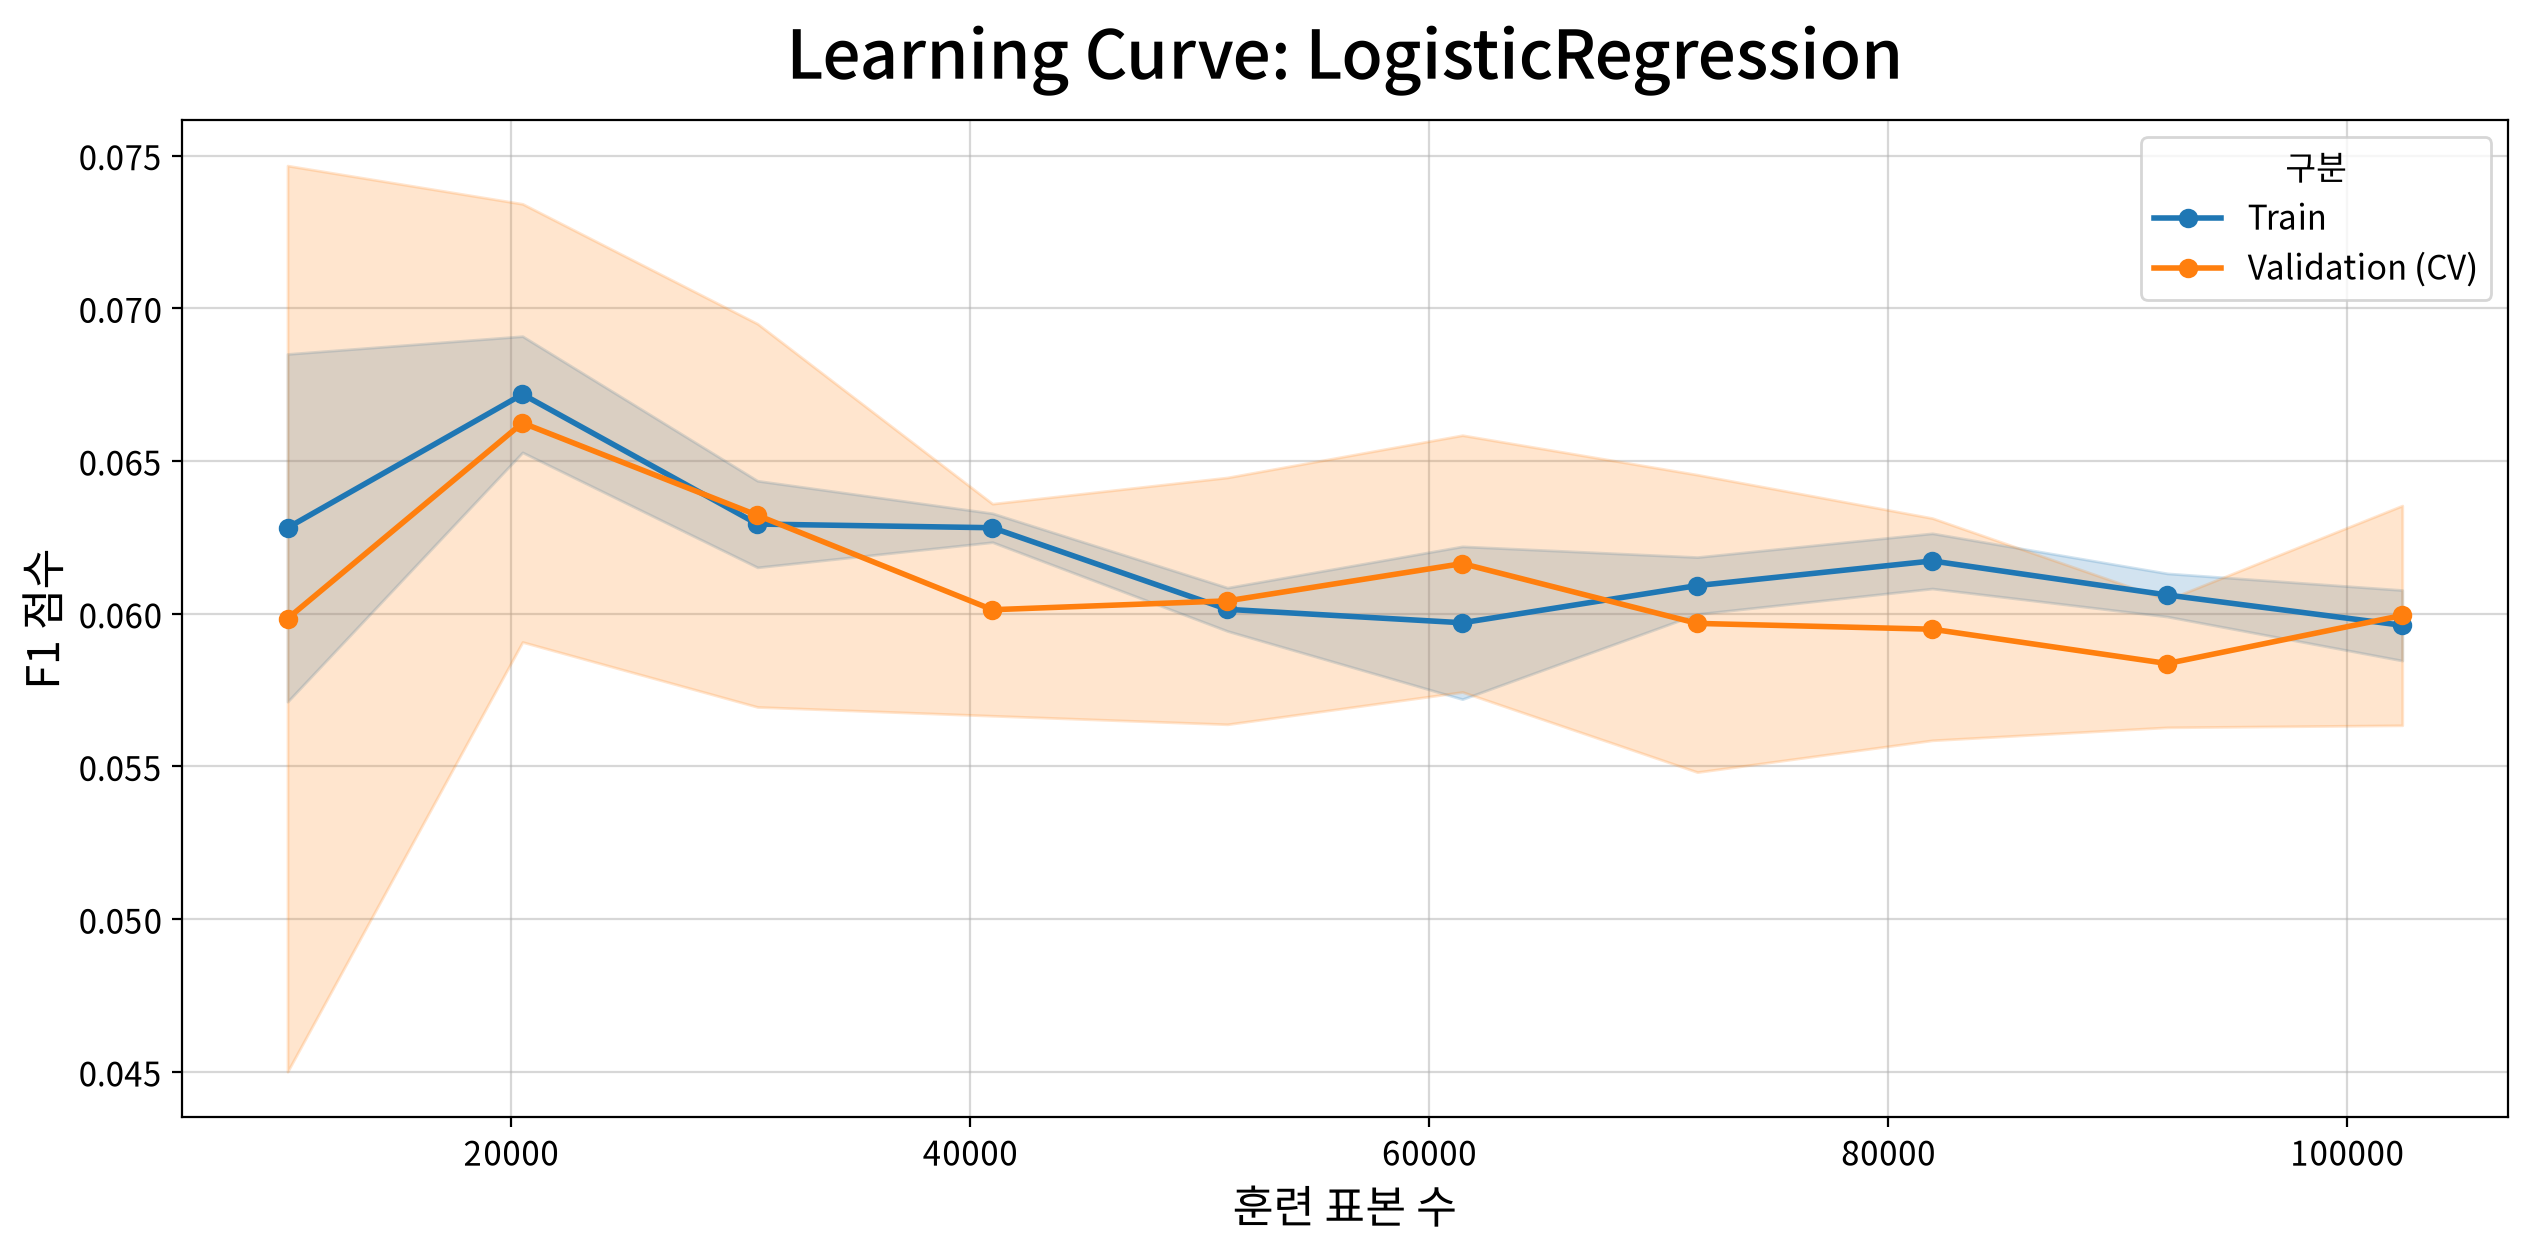

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.059348,0.059885,0.003275,0.063100,-0.000537,-0.05,일반화
PR_AUC,0.027056,0.027658,0.002671,0.030248,-0.000601,-0.06,일반화
ROC_AUC,0.818552,0.814966,0.004693,0.841417,0.003586,0.36,일반화
Recall,0.371429,0.368707,0.010884,0.375000,0.002721,0.27,일반화
Precision,0.032250,0.032592,0.001861,0.034448,-0.000341,-0.03,일반화
Accuracy,0.932392,0.933423,0.002132,0.935971,-0.001031,-0.10,일반화



◆ Fit Diagnosis: LogisticRegression  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.0593 CV=     0.0599 (±0.0033) Test=     0.0631 Gap=  -0.0005 Gap%=  -0.05% [일반화] [정상]
 - PR_AUC    Train=     0.0271 CV=     0.0277 (±0.0027) Test=     0.0302 Gap=  -0.0006 Gap%=  -0.06% [일반화] [정상]
 - ROC_AUC   Train=     0.8186 CV=     0.8150 (±0.0047) Test=     0.8414 Gap=   0.0036 Gap%=   0.36% [일반화] [정상]
 - Recall    Train=     0.3714 CV=     0.3687 (±0.0109) Test=     0.3750 Gap=   0.0027 Gap%=   0.27% [일반화] [정상]
 - Precision Train=     0.0323 CV=     0.0326 (±0.0019) Test=     0.0344 Gap=  -0.0003 Gap%=  -0.03% [일반화] [정상]
 - Accuracy  Train=     0.9324 CV=     0.9334 (±0.0021) Test=     0.9360 Gap=  -0.0010 Gap%=  -0.10% [일반화] [정상]

  ▶ 진단: ✔ 일반화 진단 (Good fit) - 설정한 gap 기준 내에서 격차가 작음
     · train ROC_AUC=0.8186 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8150


OVERFIT DIAGNOSIS — FIXED TUNED: c

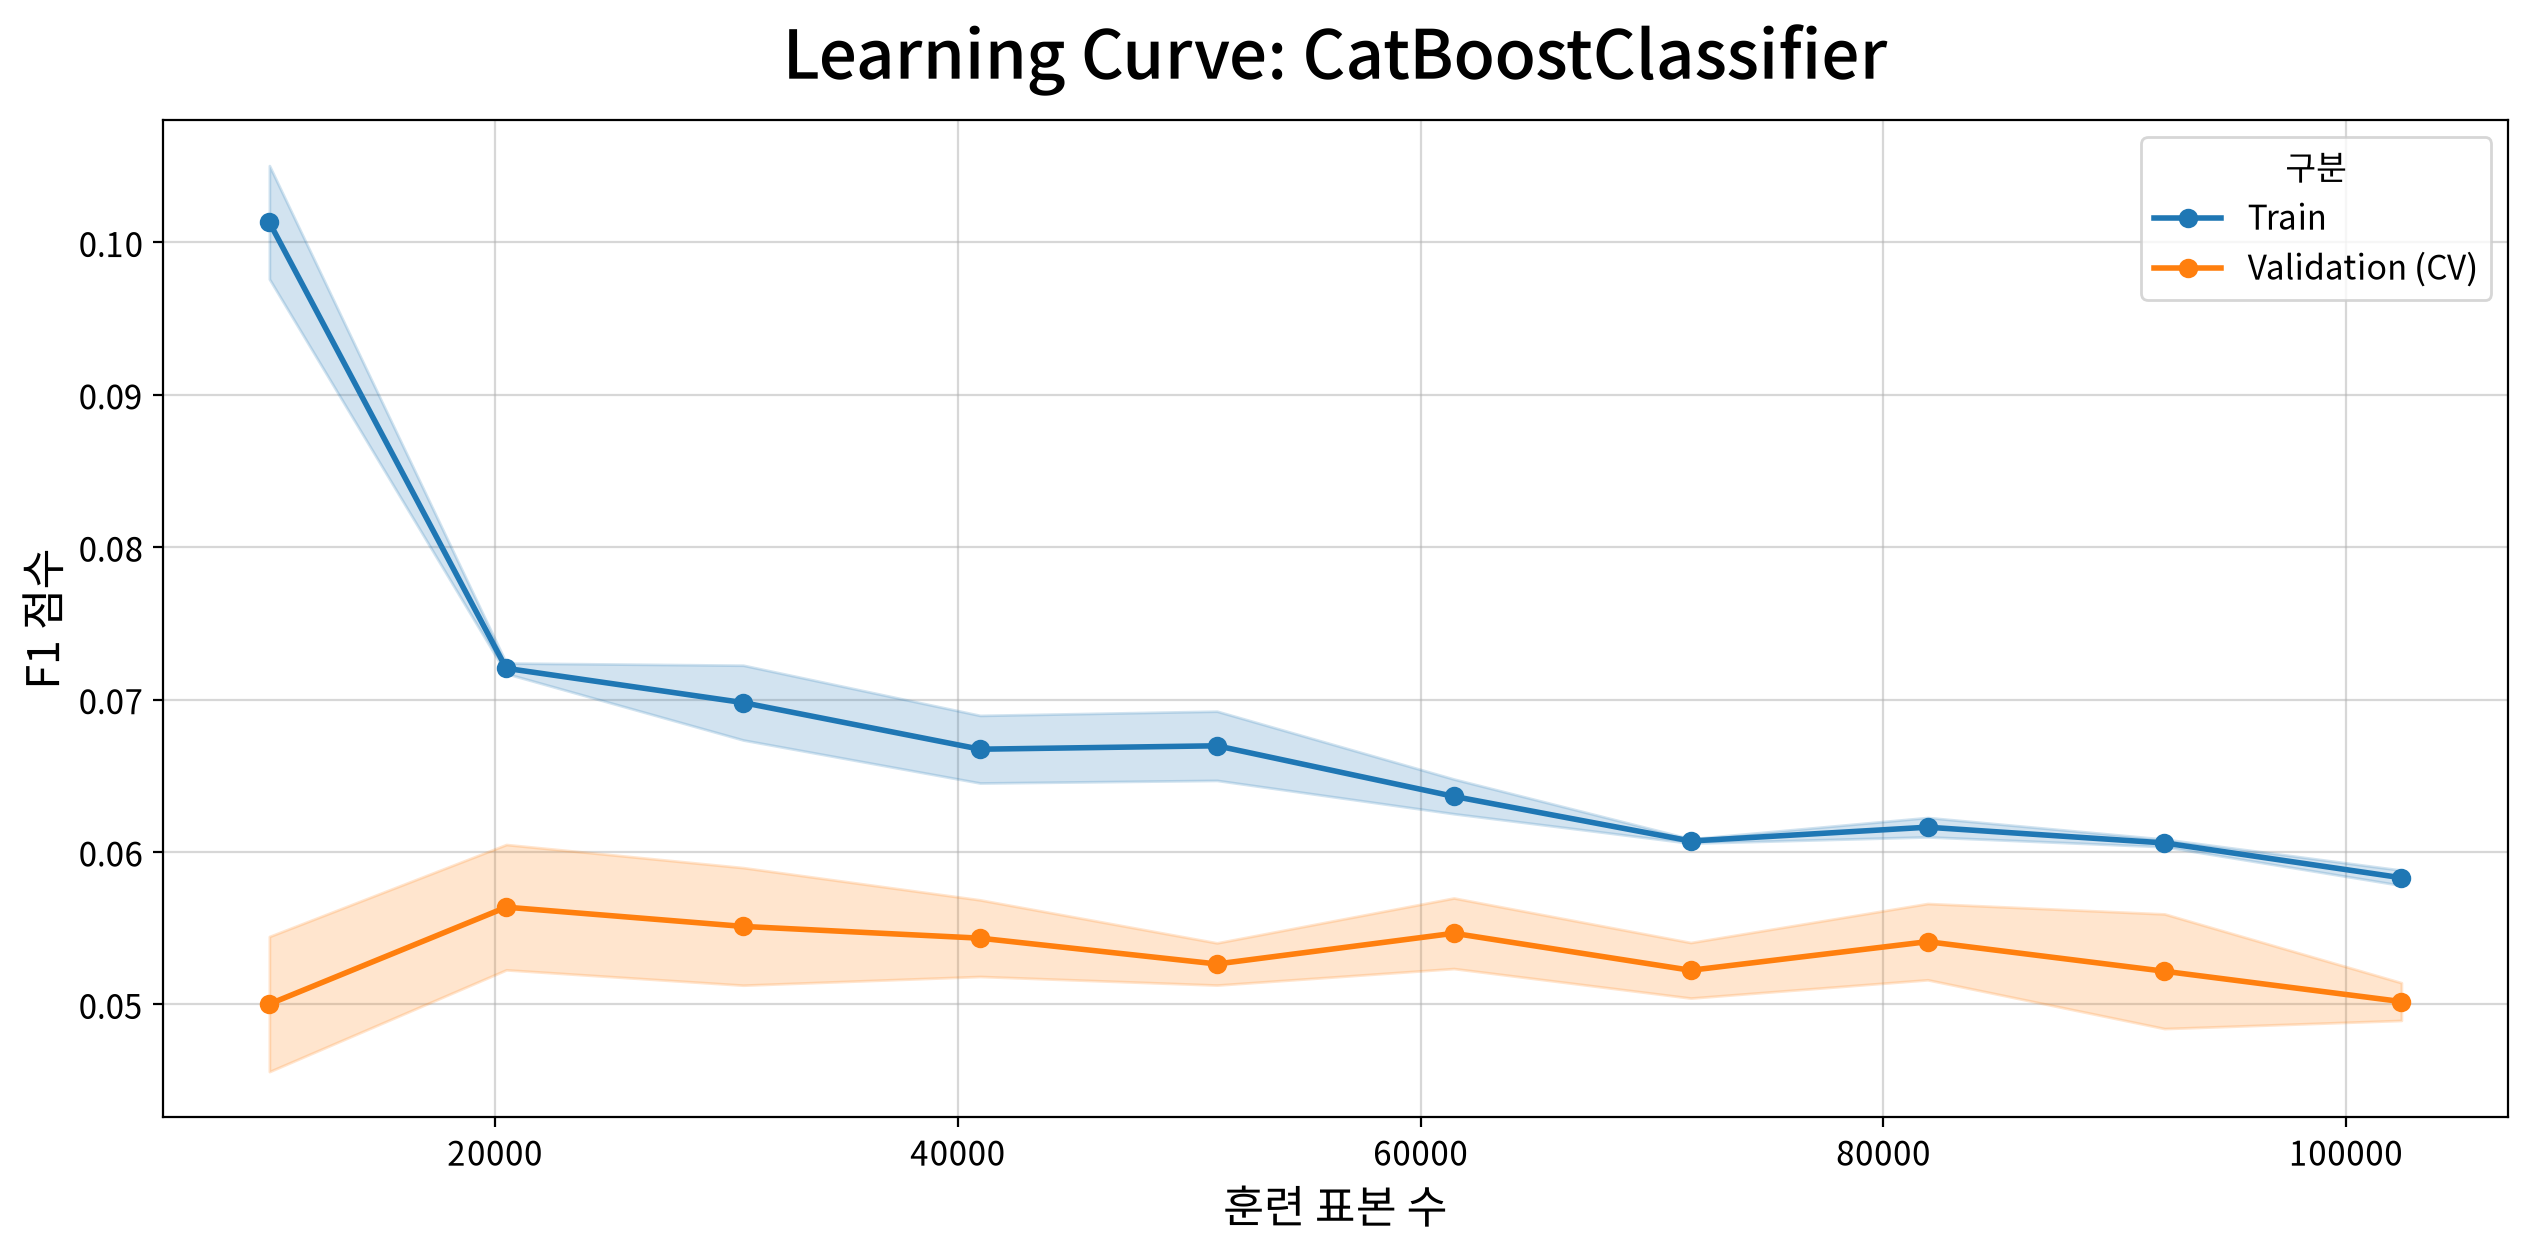

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.057346,0.050464,0.001405,0.055698,0.006882,0.69,일반화
PR_AUC,0.082735,0.029128,0.003573,0.033323,0.053607,5.36,일반화
ROC_AUC,0.836046,0.819149,0.007698,0.841995,0.016898,1.69,일반화
Recall,0.504762,0.431293,0.014008,0.472826,0.073469,7.35,일반화
Precision,0.030400,0.026801,0.000757,0.029592,0.003599,0.36,일반화
Accuracy,0.904712,0.906791,0.002191,0.907815,-0.002078,-0.21,일반화



◆ Fit Diagnosis: CatBoostClassifier  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.0573 CV=     0.0505 (±0.0014) Test=     0.0557 Gap=   0.0069 Gap%=   0.69% [일반화] [정상]
 - PR_AUC    Train=     0.0827 CV=     0.0291 (±0.0036) Test=     0.0333 Gap=   0.0536 Gap%=   5.36% [일반화] [정상]
 - ROC_AUC   Train=     0.8360 CV=     0.8191 (±0.0077) Test=     0.8420 Gap=   0.0169 Gap%=   1.69% [일반화] [정상]
 - Recall    Train=     0.5048 CV=     0.4313 (±0.0140) Test=     0.4728 Gap=   0.0735 Gap%=   7.35% [일반화] [정상]
 - Precision Train=     0.0304 CV=     0.0268 (±0.0008) Test=     0.0296 Gap=   0.0036 Gap%=   0.36% [일반화] [정상]
 - Accuracy  Train=     0.9047 CV=     0.9068 (±0.0022) Test=     0.9078 Gap=  -0.0021 Gap%=  -0.21% [일반화] [정상]

  ▶ 진단: ✔ 일반화 진단 (Good fit) - 설정한 gap 기준 내에서 격차가 작음
     · train ROC_AUC=0.8360 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8191


OVERFIT DIAGNOSIS — FIXED TUNED: l

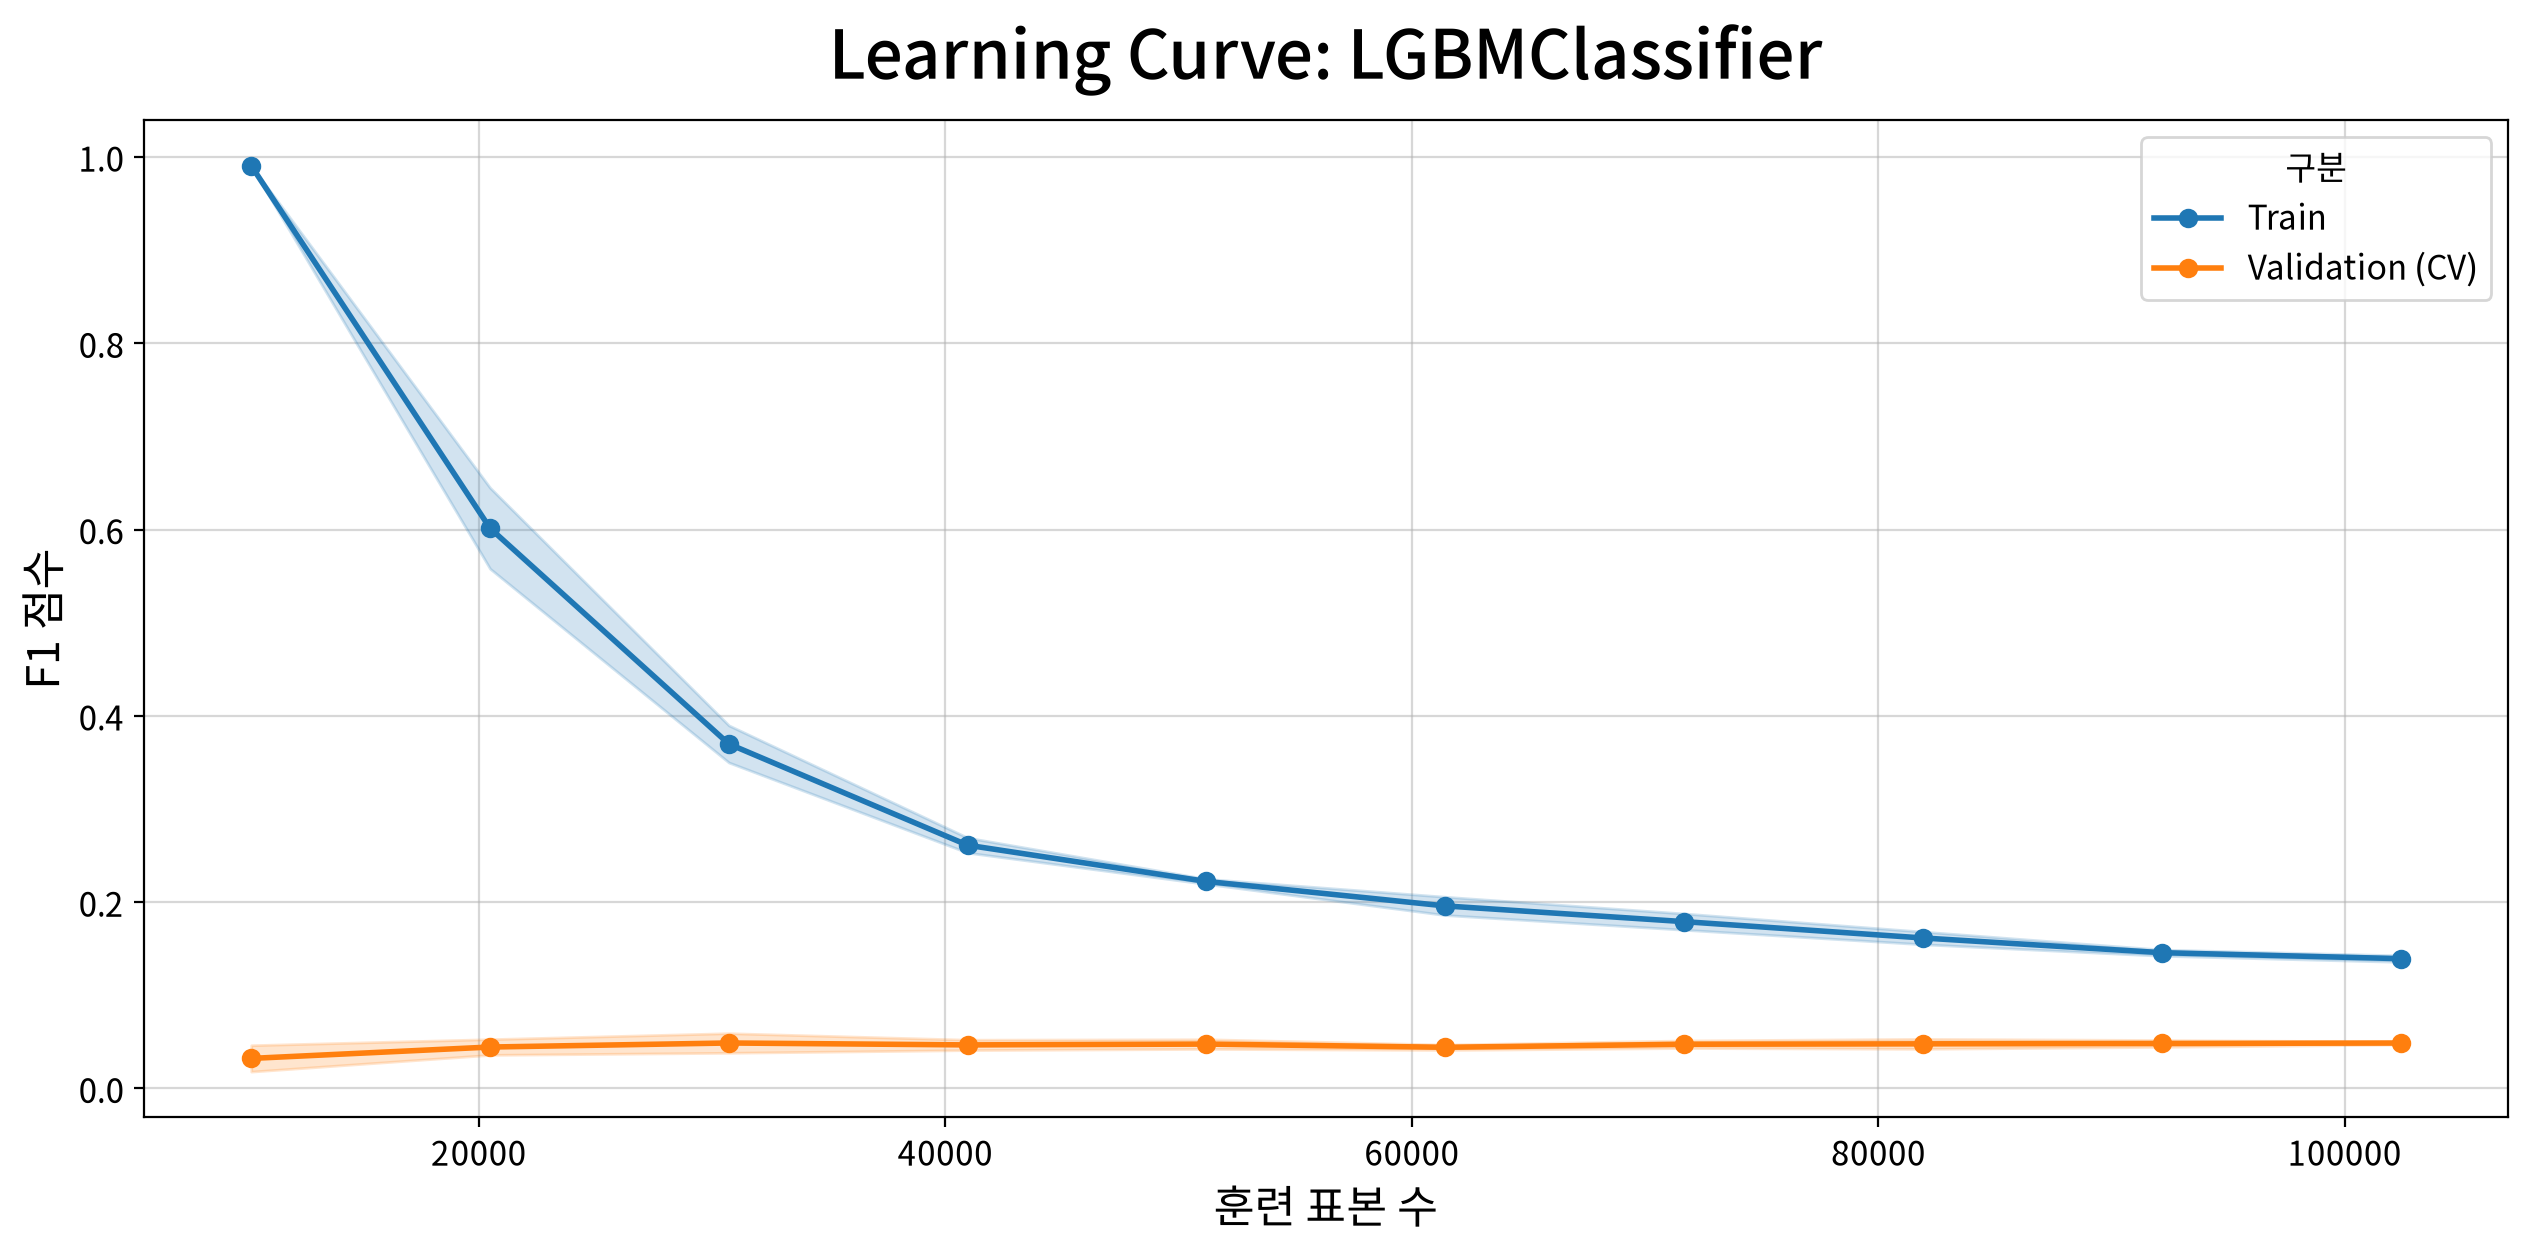

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.125712,0.047832,0.001837,0.047882,0.077881,7.79,일반화
PR_AUC,0.735525,0.020889,0.001195,0.026759,0.714636,71.46,과대적합
ROC_AUC,0.990159,0.786424,0.011447,0.812800,0.203735,20.37,과대적합
Recall,0.960544,0.345578,0.018455,0.353261,0.614966,61.50,과대적합
Precision,0.067257,0.025695,0.000972,0.025682,0.041562,4.16,일반화
Accuracy,0.923282,0.921025,0.002031,0.919221,0.002258,0.23,일반화



◆ Fit Diagnosis: LGBMClassifier  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.1257 CV=     0.0478 (±0.0018) Test=     0.0479 Gap=   0.0779 Gap%=   7.79% [일반화] [정상]
 - PR_AUC    Train=     0.7355 CV=     0.0209 (±0.0012) Test=     0.0268 Gap=   0.7146 Gap%=  71.46% [과대적합] [주의]
 - ROC_AUC   Train=     0.9902 CV=     0.7864 (±0.0114) Test=     0.8128 Gap=   0.2037 Gap%=  20.37% [과대적합] [주의]
 - Recall    Train=     0.9605 CV=     0.3456 (±0.0185) Test=     0.3533 Gap=   0.6150 Gap%=  61.50% [과대적합] [주의]
 - Precision Train=     0.0673 CV=     0.0257 (±0.0010) Test=     0.0257 Gap=   0.0416 Gap%=   4.16% [일반화] [정상]
 - Accuracy  Train=     0.9233 CV=     0.9210 (±0.0020) Test=     0.9192 Gap=   0.0023 Gap%=   0.23% [일반화] [정상]

  ▶ 진단: ▲ 과대적합 경고 (Overfit · 高분산) - 훈련↔CV 격차가 큼
     · train ROC_AUC=0.9902 (과소적합 기준 < 0.6) · CV ROC_AUC=0.7864


✓ my_diag.overfit completed for Logisti

In [14]:
overfit_results = {}
for name in ["logistic", "catboost", "lgbm"]:
    estimator = fixed_tuned_models[name]
    print("\n" + "=" * 100)
    print("OVERFIT DIAGNOSIS — FIXED TUNED:", name)
    print("=" * 100)
    common_kwargs = dict(
        estimator=estimator,
        x_train=X_train_final,
        y_train=y_train,
        x_test=X_test_final,
        y_test=y_test,
        metrics=["F1","PR_AUC","ROC_AUC","Recall","Precision","Accuracy"],
        decision_threshold=THRESHOLD,
        gap_threshold=GAP_THRESHOLD,
    )
    if name == "catboost":
        result = my_diag.overfit(
            **common_kwargs,
            fit_params={"model__cat_features": list(FINAL_CATEGORICAL)},
        )
    else:
        result = my_diag.overfit(**common_kwargs)
    overfit_results[name] = result
print("\n✓ my_diag.overfit completed for Logistic + CatBoost + LightGBM.")

In [15]:
# Final experiment audit.
print("=" * 100)
print("FINAL CONTROLLED-EXPERIMENT AUDIT")
print("=" * 100)
print("Feature count      :", len(M8_FINAL))
print("Features           :", M8_FINAL)
print("Specified base set :", BASE_10F)
print("Removed macro vars :", MACRO_REMOVE)
print("Categorical dtype  :", {c: str(X_train_final[c].dtype) for c in FINAL_CATEGORICAL})
print("Random state       :", RANDOM_STATE)
print("Threshold          :", THRESHOLD)
print("Train rows         :", len(X_train_final))
print("Test rows          :", len(X_test_final))
assert len(M8_FINAL) == 7
assert ABLATION_REMOVE == MACRO_REMOVE
assert "DTI_Missing" in M8_FINAL and "Spatial_Cluster_Region" in M8_FINAL
assert all(c not in M8_FINAL for c in MACRO_REMOVE)
assert M8_FINAL == EXPECTED_7F
assert all(
    isinstance(X_train_final[c].dtype, pd.CategoricalDtype)
    or pd.api.types.is_object_dtype(X_train_final[c].dtype)
    for c in FINAL_CATEGORICAL
)
print("\n✓ NO astype(str) applied")
print("✓ NO CatBoost constructor cat_features applied")
print("✓ CatBoost categorical columns supplied only through fit-time model__cat_features")
print("✓ Controlled 06E 7F no-macro three-model experiment complete")

FINAL CONTROLLED-EXPERIMENT AUDIT
Feature count      : 7
Features           : ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region']
Specified base set : ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
Removed macro vars : ['Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
Categorical dtype  : {'DTI_Missing': 'category', 'Spatial_Cluster_Region': 'category'}
Random state       : 3217
Threshold          : 0.015
Train rows         : 128002
Test rows          : 32001

✓ NO astype(str) applied
✓ NO CatBoost constructor cat_features applied
✓ CatBoost categorical columns supplied only through fit-time model__cat_features
✓ Controlled 06E 7F no-macro three-model experiment com

## 7F No-Macro vs 10F With-Macro — controlled CatBoost comparison

이 비교에서는 06E에서 동일한 고정 튜닝 파라미터로 최종 적합된 **7F No-Macro CatBoost**와 기존 M8 실험에서 같은 고정 파라미터로 적합·저장된 **10F With-Macro CatBoost**를 비교한다.

10F 비교에는 `SFLLD_M8_11F.../importance/catboost_no_harp_10F_fixed.pkl`을 사용한다. 두 모델의 CatBoost 핵심 파라미터와 입력 feature를 실행 중 audit하여 비교

In [16]:
from pathlib import Path
import joblib
FEATURES_7F = ["FICO_Score","Original_DTI","Original_CLTV","Original_Interest_Rate","Number_of_Borrowers","DTI_Missing","Spatial_Cluster_Region"]
CATEGORICAL_7F = ["DTI_Missing","Spatial_Cluster_Region"]
FEATURES_10F = ["FICO_Score","Original_DTI","Original_CLTV","Original_Interest_Rate","Number_of_Borrowers","DTI_Missing","Spatial_Cluster_Region","Housing_HPI_Growth_12M","BLS_Unemployment_Rate_Change_12M_Final","Regular_MSA_Macro_Cluster_A"]
CATEGORICAL_10F = ["DTI_Missing","Spatial_Cluster_Region","Regular_MSA_Macro_Cluster_A"]
assert M8_FINAL == FEATURES_7F
catboost_7F = fixed_tuned_models["catboost"]
MODEL_10F_CANDIDATES = [
    Path("SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams") / "importance" / "catboost_no_harp_10F_fixed.pkl",
    Path("results") / "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams" / "importance" / "catboost_no_harp_10F_fixed.pkl",
    Path("../results") / "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams" / "importance" / "catboost_no_harp_10F_fixed.pkl",
]
MODEL_10F_PATH = next((p.resolve() for p in MODEL_10F_CANDIDATES if p.exists()), None)
if MODEL_10F_PATH is None:
    raise FileNotFoundError("Cannot find catboost_no_harp_10F_fixed.pkl. Searched:\n" + "\n".join(str(p.resolve()) for p in MODEL_10F_CANDIDATES))
catboost_10F = joblib.load(MODEL_10F_PATH)
print("7F model : fixed_tuned_models['catboost'] from current 06E run")
print("10F model:", MODEL_10F_PATH)

7F model : fixed_tuned_models['catboost'] from current 06E run
10F model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl


In [17]:
def model_features(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        inner = model.named_steps["model"]
        if hasattr(inner, "feature_names_"):
            return list(inner.feature_names_)
    if hasattr(model, "feature_names_"):
        return list(model.feature_names_)
    return None
def catboost_core_params(model):
    params = model.get_params(deep=True)
    return {
        "depth": params.get("model__depth", params.get("depth")),
        "iterations": params.get("model__iterations", params.get("iterations")),
        "learning_rate": params.get("model__learning_rate", params.get("learning_rate")),
    }
features_7f_loaded = model_features(catboost_7F)
features_10f_loaded = model_features(catboost_10F)
params_7f = catboost_core_params(catboost_7F)
params_10f = catboost_core_params(catboost_10F)
print("7F loaded features :", features_7f_loaded)
print("7F expected features:", FEATURES_7F)
print("10F loaded features :", features_10f_loaded)
print("10F expected features:", FEATURES_10F)
print("7F core parameters :", params_7f)
print("10F core parameters:", params_10f)
if features_7f_loaded is not None:
    assert features_7f_loaded == FEATURES_7F, "7F feature audit failed"
if features_10f_loaded is not None:
    assert features_10f_loaded == FEATURES_10F, "10F feature audit failed"
assert params_7f == {"depth":4,"iterations":500,"learning_rate":0.03}, f"7F parameter audit failed: {params_7f}"
assert params_10f == {"depth":4,"iterations":500,"learning_rate":0.03}, f"10F parameter audit failed: {params_10f}"
print("✓ MODEL AUDIT PASSED: same fixed tuned CatBoost parameters, 7F vs 10F feature sets verified")

7F loaded features : ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region']
7F expected features: ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region']
10F loaded features : ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
10F expected features: ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
7F core parameters : {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}
10F core parameters: {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}
✓ MODEL AU

In [18]:
VALIDATION_CANDIDATES = [
    Path(r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_validation_ML_ready.parquet"),
    Path("../data/output/model_ready/SFLLD_regular_PIT_validation_ML_ready.parquet"),
    Path("data/output/model_ready/SFLLD_regular_PIT_validation_ML_ready.parquet"),
    Path("SFLLD_regular_PIT_validation_ML_ready.parquet"),
]
VALIDATION_PATH = next((p.resolve() for p in VALIDATION_CANDIDATES if p.exists()), None)
if VALIDATION_PATH is None:
    raise FileNotFoundError("Cannot find SFLLD_regular_PIT_validation_ML_ready.parquet. Searched:\n" + "\n".join(str(p.resolve()) for p in VALIDATION_CANDIDATES))
validation_data = pd.read_parquet(VALIDATION_PATH)
validation_available_categorical = [c for c in CATEGORICAL_COLS if c in validation_data.columns]
validation_data = my_qtcheck.set_type(validation_data, as_category=validation_available_categorical)
required_validation = list(dict.fromkeys(FEATURES_10F + [TARGET,"Loan_ID"]))
missing_validation = [c for c in required_validation if c not in validation_data.columns]
if missing_validation:
    raise KeyError(f"Validation columns missing: {missing_validation}")
data = df
test_idx = X_test.index
print("Internal test:", len(test_idx))
print("Validation   :", len(validation_data))
print("Test event rate      :", data.loc[test_idx,TARGET].mean())
print("Validation event rate:", validation_data[TARGET].mean())

<class 'pandas.DataFrame'>
RangeIndex: 49038 entries, 0 to 49037
Data columns (total 56 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Loan_ID                                 49038 non-null  str           
 1   FICO_Score                              49038 non-null  float64       
 2   First_Payment_Date                      49038 non-null  datetime64[us]
 3   First_Time_Homebuyer                    49038 non-null  category      
 4   Maturity_Date                           49038 non-null  datetime64[us]
 5   MSA                                     49038 non-null  category      
 6   MI_Percentage                           49038 non-null  float64       
 7   Number_of_Units                         49038 non-null  category      
 8   Occupancy_Status                        49038 non-null  category      
 9   Original_CLTV                           49038 non-null  float

In [19]:
X_test_7F = data.loc[test_idx,FEATURES_7F].copy()
X_val_7F = validation_data[FEATURES_7F].copy()
X_test_10F = data.loc[test_idx,FEATURES_10F].copy()
X_val_10F = validation_data[FEATURES_10F].copy()
for c in CATEGORICAL_7F:
    X_test_7F[c] = X_test_7F[c].astype("category")
    X_val_7F[c] = X_val_7F[c].astype("category")
for c in CATEGORICAL_10F:
    X_test_10F[c] = X_test_10F[c].astype("category")
    X_val_10F[c] = X_val_10F[c].astype("category")
predictions = {
    "7F":{"Test":catboost_7F.predict_proba(X_test_7F)[:,1],"Validation":catboost_7F.predict_proba(X_val_7F)[:,1]},
    "10F":{"Test":catboost_10F.predict_proba(X_test_10F)[:,1],"Validation":catboost_10F.predict_proba(X_val_10F)[:,1]},
}
print("Prediction completed.")
print("7F Test:",len(predictions["7F"]["Test"]),"10F Test:",len(predictions["10F"]["Test"]))
print("7F Validation:",len(predictions["7F"]["Validation"]),"10F Validation:",len(predictions["10F"]["Validation"]))

Prediction completed.
7F Test: 32001 10F Test: 32001
7F Validation: 49038 10F Validation: 49038


In [20]:
def ranking_metrics(y,score,ids,label,cohort):
    y=np.asarray(y,dtype=int)
    score=np.asarray(score)
    ids=np.asarray(ids,dtype=str)
    assert len(y)==len(score)==len(ids)
    assert np.isfinite(score).all()
    assert set(np.unique(y))=={0,1}
    auc=roc_auc_score(y,score)
    fpr,tpr,_=roc_curve(y,score)
    row={"Model":label,"Cohort":cohort,"N":len(y),"Events":int(y.sum()),"Event_Rate":y.mean(),"ROC_AUC":auc,"Gini":2*auc-1,"PR_AUC_AP":average_precision_score(y,score),"KS":float(np.max(tpr-fpr))}
    order=np.lexsort((ids,-score))
    for share in [0.05,0.20]:
        k=int(np.ceil(len(y)*share))
        capture=y[order[:k]].sum()/y.sum()
        suffix=str(int(100*share))
        row["Top_"+suffix+"_N"]=k
        row["Capture_"+suffix]=capture
        row["Lift_"+suffix]=capture/(k/len(y))
    return row
rows=[]
for label in ["7F","10F"]:
    rows.append(ranking_metrics(data.loc[test_idx,TARGET],predictions[label]["Test"],data.loc[test_idx,"Loan_ID"],label,"Test"))
    rows.append(ranking_metrics(validation_data[TARGET],predictions[label]["Validation"],validation_data["Loan_ID"],label,"Validation"))
metrics=pd.DataFrame(rows)
display(metrics)

,Model,Cohort,N,Events,Event_Rate,ROC_AUC,Gini,PR_AUC_AP,KS,Top_5_N,Capture_5,Lift_5,Top_20_N,Capture_20,Lift_20
0,7F,Test,32001,184,0.005750,0.841995,0.683991,0.033323,0.548727,1601,0.298913,5.974713,6401,0.744565,3.722361
1,7F,Validation,49038,380,0.007749,0.822781,0.645562,0.037620,0.524948,2452,0.278947,5.578720,9808,0.668421,3.341969
2,10F,Test,32001,184,0.005750,0.855422,0.710844,0.047680,0.572938,1601,0.358696,7.169656,6401,0.755435,3.776702
3,10F,Validation,49038,380,0.007749,0.825323,0.650645,0.041518,0.518644,2452,0.300000,5.999755,9808,0.668421,3.341969


In [21]:
comparison=metrics.set_index(["Cohort","Model"])[["ROC_AUC","PR_AUC_AP","KS","Capture_5","Capture_20","Lift_5","Lift_20"]]
delta=comparison.xs("10F",level="Model")-comparison.xs("7F",level="Model")
display(delta)
for cohort in ["Test","Validation"]:
    d=delta.loc[cohort]
    direction="상승" if d.ROC_AUC>0 else "하락" if d.ROC_AUC<0 else "동일"
    display(Markdown(f"**{cohort} 해석:** 10F−7F ROC-AUC 차이는 {d.ROC_AUC:+.6f}로 {direction}했다. AP 차이는 {d.PR_AUC_AP:+.6f}, 상위 5% 포착률 차이는 {d.Capture_5:+.4f}, 상위 20% 포착률 차이는 {d.Capture_20:+.4f}이다. 이 결과는 동일한 고정 튜닝 파라미터를 사용한 7F No-Macro와 10F With-Macro의 예측 성능 비교이며, 인과적 효과를 의미하지 않는다."))

,ROC_AUC,PR_AUC_AP,KS,Capture_5,Capture_20,Lift_5,Lift_20
Cohort,,,,,,,
Test,0.013427,0.014357,0.024212,0.059783,0.01087,1.194943,0.054341
Validation,0.002542,0.003898,-0.006304,0.021053,0.00000,0.421035,0.000000


**Test 해석:** 10F−7F ROC-AUC 차이는 +0.013427로 상승했다. AP 차이는 +0.014357, 상위 5% 포착률 차이는 +0.0598, 상위 20% 포착률 차이는 +0.0109이다. 이 결과는 동일한 고정 튜닝 파라미터를 사용한 7F No-Macro와 10F With-Macro의 예측 성능 비교이며, 인과적 효과를 의미하지 않는다.

**Validation 해석:** 10F−7F ROC-AUC 차이는 +0.002542로 상승했다. AP 차이는 +0.003898, 상위 5% 포착률 차이는 +0.0211, 상위 20% 포착률 차이는 +0.0000이다. 이 결과는 동일한 고정 튜닝 파라미터를 사용한 7F No-Macro와 10F With-Macro의 예측 성능 비교이며, 인과적 효과를 의미하지 않는다.

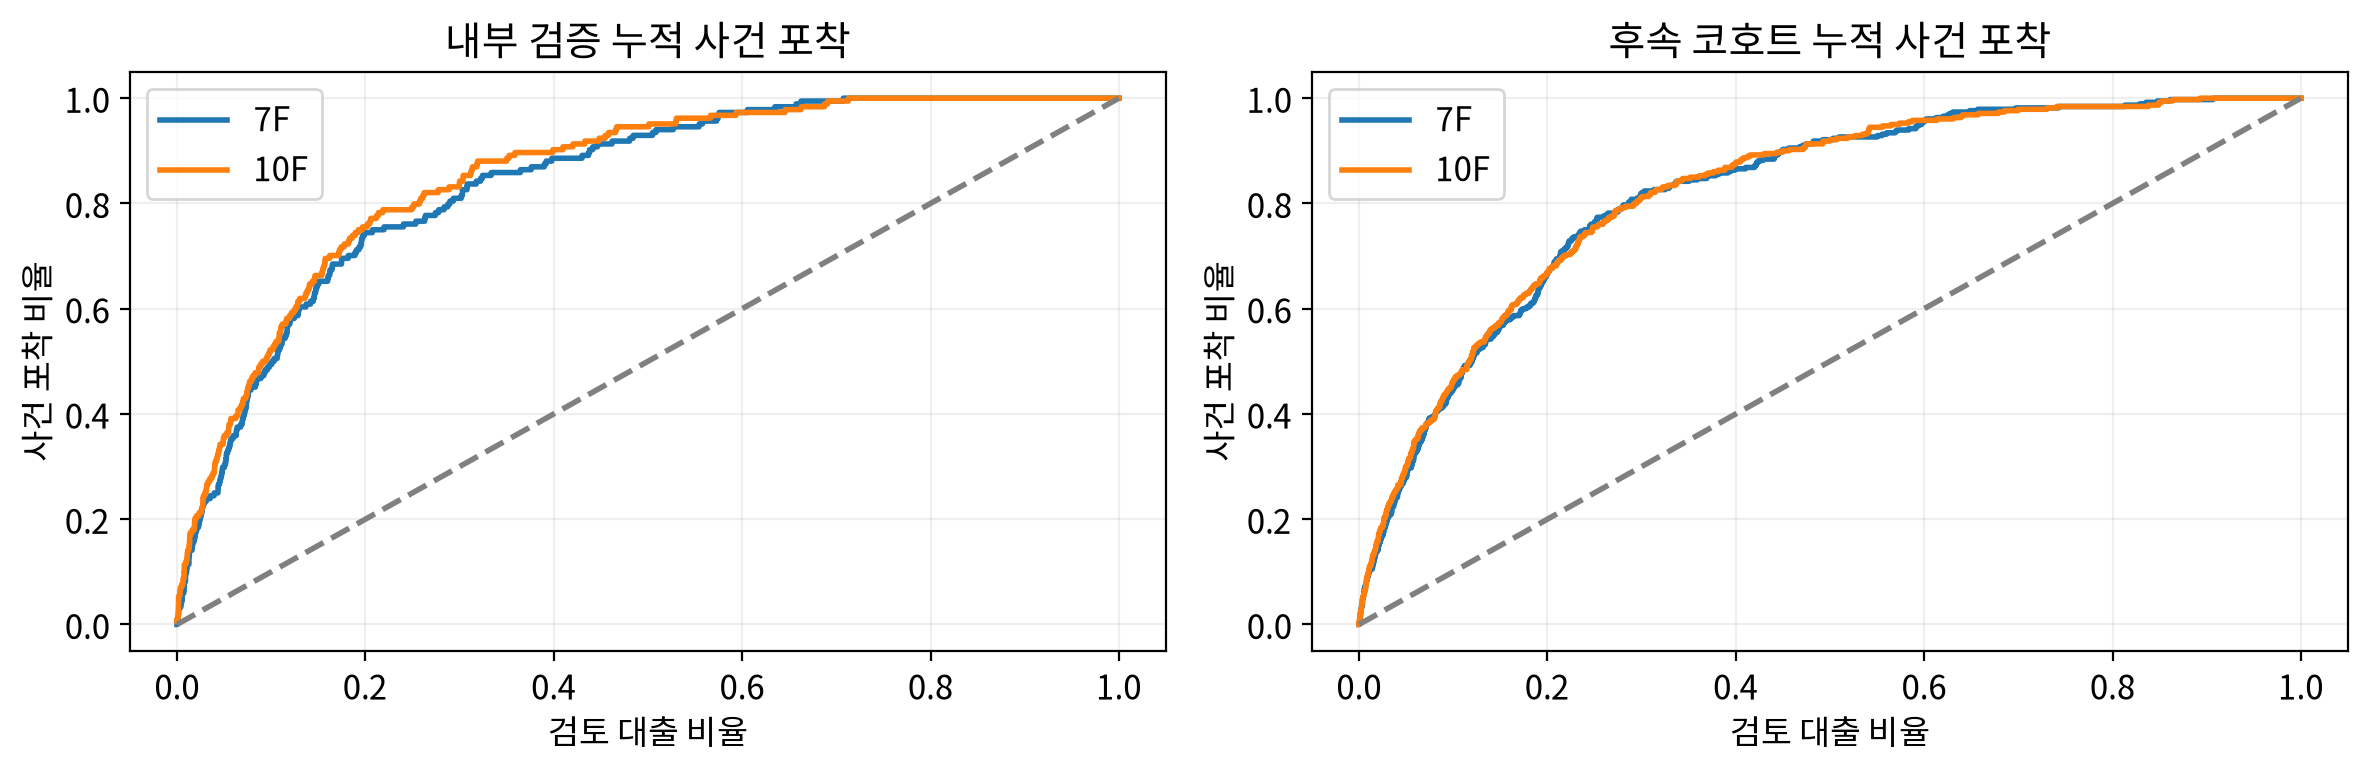

In [22]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(12,4))
for label in ["7F","10F"]:
    y_test=data.loc[test_idx,TARGET].to_numpy()
    ids_test=data.loc[test_idx,"Loan_ID"].to_numpy(dtype=str)
    score_test=predictions[label]["Test"]
    order_test=np.lexsort((ids_test,-score_test))
    axes[0].plot(np.arange(1,len(y_test)+1)/len(y_test),np.cumsum(y_test[order_test])/y_test.sum(),label=label)
    y_val=validation_data[TARGET].to_numpy()
    ids_val=validation_data["Loan_ID"].to_numpy(dtype=str)
    score_val=predictions[label]["Validation"]
    order_val=np.lexsort((ids_val,-score_val))
    axes[1].plot(np.arange(1,len(y_val)+1)/len(y_val),np.cumsum(y_val[order_val])/y_val.sum(),label=label)
axes[0].set_title("내부 검증 누적 사건 포착")
axes[1].set_title("후속 코호트 누적 사건 포착")
for ax in axes:
    ax.set_xlabel("검토 대출 비율")
    ax.set_ylabel("사건 포착 비율")
    ax.plot([0,1],[0,1],"--",color="gray")
    ax.legend()
    ax.grid(alpha=.2)
fig.tight_layout()
plt.show()

### 거시경제 변수 추가 효과 해석

7F No-Macro 모델과 10F With-Macro 모델을 비교한 결과, **전반적으로 10F 모델이 더 우수한 예측 성능을 보였으며, 특히 고위험 대출의 우선순위화와 상위 위험군 포착에서 거시경제 변수의 추가적인 가치가 확인되었다.**

내부 Test에서 10F 모델의 ROC-AUC는 **0.8420에서 0.8554로 0.0134 증가**하였고, PR-AUC(AP)는 **0.0333에서 0.0477로 증가**하였다. 특히 상위 5% 사건 포착률은 **29.89%에서 35.87%로 5.98%p 증가**하였으며, Lift@5% 역시 **5.97에서 7.17로 향상**되었다. 이는 거시경제 변수를 추가한 10F 모델이 전체 대출 중 실제 위험도가 높은 대출을 상위 위험군에 배치하는 능력을 개선했음을 보여준다.

독립적인 후속 Validation에서도 10F 모델의 우위는 주요 지표에서 유지되었다. ROC-AUC는 **0.8228에서 0.8253으로 증가**하였고, PR-AUC(AP)는 **0.0376에서 0.0415로 증가**하였다. 특히 상위 5% 사건 포착률은 **27.89%에서 30.00%로 2.11%p 증가**하였으며, Lift@5%도 **5.58에서 6.00으로 향상**되었다. 따라서 거시경제 변수의 추가 효과가 내부 Test에만 국한되지 않고 독립적인 후속 코호트의 최상위 위험군 식별에서도 유지되는 것을 확인할 수 있다.

다만 Validation에서 전체적인 개선 폭은 Test보다 작았다. Capture@20%는 두 모델 모두 **66.84%로 동일**하였으며, KS는 10F에서 소폭 감소하였다. 따라서 거시경제 변수의 가장 뚜렷한 장점은 모든 평가 지표의 일관된 향상이라기보다, **고위험 대출을 상위 위험 구간에 보다 효과적으로 집중시키는 능력의 개선**으로 해석하는 것이 적절하다.

종합하면, **10F With-Macro 모델은 7F No-Macro 모델보다 전반적으로 더 나은 위험 순위화 성능을 보였으며, 특히 실무적으로 중요한 상위 5% 고위험 대출 식별에서 일관된 개선을 나타냈다.** 이는 주택가격 변화, 실업률 변화 및 지역 거시경제 군집 정보가 차주의 개별 신용 특성만으로는 충분히 포착되지 않는 추가적인 위험 정보를 제공할 가능성을 보여준다.

본 결과는 동일한 고정 튜닝 파라미터를 적용한 7F와 10F 모델의 예측 성능 비교이며, 거시경제 변수의 인과적 효과를 의미하지 않는다.